# FSRCNN Image Super-Resolution in PyTorch

Portfolio version by `@pkim02`.

This notebook is a cleaned project version derived from coursework. The implementation code and executed results are preserved, while submission instructions, personal identifiers, assignment boilerplate, and course-provided image references were removed.

**Project focus:** A PyTorch implementation of FSRCNN for single-image super-resolution, comparing learned reconstruction against bicubic interpolation.


## Implementation Notes

The code cells below contain the implemented model, training, evaluation, and visualization workflow. Most executed outputs are kept so the notebook can be reviewed without rerunning the full experiment.


In [1]:
import datetime
print("This code is written at " + str(datetime.datetime.now()))


This code is written at 2026-03-31 04:57:44.557719


In [5]:
"Environment setting"

!bash requirements.sh

# If error occurs, run the below command line

#!pip install scikit-image==0.19.3
#!pip install opencv-python==4.11.0.86

#!pip uninstall numpy scikit-image -y
#!pip install numpy==1.26.4 scikit-image==0.22.0


  Using cached scikit_image-0.19.3-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (14.0 MB)
     |████████████████████████████████| 17.3 MB 12.1 MB/s eta 0:00:01
ERROR: After October 2020 you may experience errors when installing or updating packages. This is because pip will change the way that it resolves dependency conflicts.

We recommend you use --use-feature=2020-resolver to test your packages with the new resolver before it becomes the default.

imageio 2.35.1 requires pillow>=8.3.2, but you'll have pillow 8.1.2 which is incompatible.


In [6]:
import torch
import torch.nn as nn
from torch.utils.data.dataset import Dataset
import matplotlib.pyplot as plt
import numpy as np
import skimage
import os
import glob
from skimage.io import imread
import skimage
import cv2

os.environ["CUDA_VISIBLE_DEVICES"]="0"


In [7]:
def seed_everything(seed: int):
    import random, os
    import numpy as np
    import torch

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(123)


In [5]:

# "Preprocessing of Training Dataset"
# "Generating HR_patches_from_T91.npy"
# "Note that HR_patches_from_T91.npy file already exist in ./dataset/lab05 folder"

# T91_directory = "./dataset/lab05/T91/"
# T91_images = sorted(glob.glob(T91_directory + "*.png"))

# print("The number of training images : ",len(T91_images))

# # Augmentation setting
# SCALE = [1, 0.9, 0.8, 0.7, 0.6, 2]
# PATCH_SIZE = 64
# STRIDE = 64
# IS_GRAY = True
# HR_SET = []

# def load_img(filepath, is_gray):
#     img = imread(filepath)
#     ch = img.ndim
#     if ch == 2:
#         img = skimage.color.gray2rgb(img)
#     if is_gray:
#         img = skimage.color.rgb2ycbcr(img)
#     return img / 255.

# for idx in range(len(T91_images)):
#     print("\r Processing ", idx+1," / ",len(T91_images), end = '')
#     image_directory = T91_images[idx]
#     for s in SCALE:
#         # load image
#         image = load_img(image_directory, IS_GRAY) # is_gary : YCbCr or RGB
#         image = cv2.resize(image,dsize=None,fx=s,fy=s,interpolation=cv2.INTER_CUBIC)
#         image = image.clip(0,1)
#         # generate HR patch
#         h,w,_ = image.shape
#         for i in range(0, h-PATCH_SIZE, STRIDE):
#             for j in range(0, w-PATCH_SIZE, STRIDE):
#                 hr_patch = image[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :]
#                 if IS_GRAY:
#                     hr_patch = hr_patch[:,:,0]
#                 HR_SET.append(hr_patch)

# print("\nThe number of training patches : ",len(HR_SET))
# np.save('./dataset/lab05/HR_patches_from_T91.npy', HR_SET)
# print("Training patches are successfully saved")


In [10]:
import torchvision.transforms.functional as f
from torchvision.transforms import InterpolationMode
import random
from torchvision import transforms
print('STEP 1: DEFINE DATASET')

class T91_images(Dataset):
    def __init__(self, data_dir = "./dataset/lab05/HR_patches_from_T91.npy", HR_patch_size = 64, scale_factor = 4):
        super(T91_images, self).__init__()
        self.HR_patches_np = np.load(data_dir) # pre-processed patches
        self.HR_patch_size = HR_patch_size
        self.scale_factor = scale_factor

    def __getitem__(self, idx):
        HR_patch_np = self.HR_patches_np[idx] # high resolution patch
        HR_patch=torch.from_numpy(HR_patch_np).type(torch.FloatTensor)
        HR_patch = HR_patch.unsqueeze(0) # size : 1(c) x 64(h) x 64(w)

        # Flip (randomness = 0.5) left and right
        # Random horizontal flip, probability = 0.5
        if torch.rand(1).item() < 0.5:
            HR_patch = torch.flip(HR_patch, dims=[2])  # flip width axis of (C,H,W)
        

        # Rotation (random rotation with 0,90,180,270 degree)
        # Random rotation by 0, 90, 180, or 270 degrees on spatial axes
        HR_patch = torch.rot90(HR_patch, k=torch.randint(0, 4, (1,)).item(), dims=[1, 2])


        # Resizing for LR Patch
        # Downsample 64x64 HR patch to 16x16 LR patch using bicubic interpolation
        LR_patch = f.resize(HR_patch, [self.HR_patch_size // self.scale_factor, self.HR_patch_size // self.scale_factor],
                            interpolation=InterpolationMode.BICUBIC)


        return HR_patch, LR_patch # Y-channel patches

    def __len__(self):
        return len(self.HR_patches_np)

class Set5(Dataset):
    def __init__(self, data_dir = './dataset/lab05/Set5/', scale_factor=4):
        super(Set5, self).__init__()
        self.image_filenames = [os.path.join(data_dir, x) for x in sorted(os.listdir(data_dir))]
        self.scale_factor = scale_factor

    def load_img(self, filepath):
        img = skimage.io.imread(filepath)
        ch = img.ndim
        if ch == 2:
            img = skimage.color.gray2rgb(img)
        img = skimage.color.rgb2ycbcr(img) / 255.

        h, w = img.shape[:-1]
        img = torch.from_numpy(img).type(torch.FloatTensor).permute(2,0,1) # HWC 2 CHW

        ## Cropping
        HR_img = img[:, : h-(h%self.scale_factor), : w-(w%self.scale_factor)]

        ## Resizing to Low Resolution image
        # Downsample HR image to LR image using bicubic interpolation
        LR_img = f.resize(HR_img, [HR_img.shape[1] // self.scale_factor, HR_img.shape[2] // self.scale_factor],
                          interpolation=InterpolationMode.BICUBIC)

        # Upsample LR image back to HR size using bicubic interpolation
        BC_img = f.resize(LR_img, [HR_img.shape[1], HR_img.shape[2]],
                          interpolation=InterpolationMode.BICUBIC)


        return HR_img, LR_img, BC_img#matches output from resizing

    def __getitem__(self, idx):
        # load image
        (HR_img,LR_img,BC_img) = self.load_img(self.image_filenames[idx])

        return HR_img, LR_img, BC_img # YCbCr images

    def __len__(self):
        return len(self.image_filenames)


STEP 1: DEFINE DATASET


In [11]:
print('STEP 2: LOADING DATASET')

scale_factor = 4 # 1/4 down scaling

train_dataset = T91_images(data_dir = "./dataset/lab05/HR_patches_from_T91.npy", HR_patch_size = 64, scale_factor = scale_factor)
test_dataset = Set5(data_dir = "./dataset/lab05/Set5/", scale_factor = scale_factor)

## default batch_size 64
train_loader = torch.utils.data.DataLoader(dataset = train_dataset,
                                           batch_size = 64,
                                           shuffle = True, num_workers = 4)
test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = 1,
                                          shuffle = False)


STEP 2: LOADING DATASET


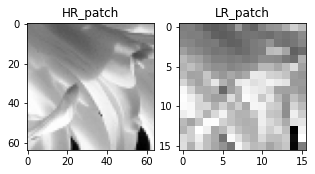

In [12]:
(HR_patch, LR_patch) = train_dataset[400]
fig = plt.figure(figsize=(5,3))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)
ax1.imshow(HR_patch.squeeze(0).numpy(), cmap='gray')
ax1.set_title("HR_patch")
ax2.imshow(LR_patch.squeeze(0).numpy(), cmap='gray')
ax2.set_title("LR_patch")
plt.show()


In [17]:
print('STEP 3: CREATE MODEL CLASS (FSRCNN)')

class FSRCNN(nn.Module):
    def __init__(self, scale_factor = 4):
        super(FSRCNN, self).__init__()  # nn.Module parent class initialized.

        # Feature extraction
        # 1-channel LR input, d=56 feature maps output using a 5x5 convolution
        self.feature_extraction = nn.Sequential(
            nn.Conv2d(1, 56, kernel_size=5, padding=2),  # keep spatial size same with padding=2
            nn.PReLU(56)  # PReLU activation for 56 channels
        )

        # Shrinking:
        #channel dimension from d=56 to s=12 using 1x1 convolution
        self.shrinking = nn.Sequential(
            nn.Conv2d(56, 12, kernel_size=1),  # 1x1 conv changes channels only
            nn.PReLU(12)  # activation for 12 channels
        )

        # Non-linear mapping:
        # m=4 repeated 3x3 conv in low dimensional feature space
        mapping = []
        for _ in range(4):
            mapping += [
                nn.Conv2d(12, 12, kernel_size=3, padding=1),  # 3x3 conv for consistent spatial size
                nn.PReLU(12)  # PReLU after conv
            ]
        self.mapping = nn.Sequential(*mapping)  # pack mapping layers into Sequential

        # Expanding:
        # expand channel dimension from s=12 to d=56
        self.expanding = nn.Sequential(
            nn.Conv2d(12, 56, kernel_size=1),  # 1x1 conv restores channels
            nn.PReLU(56)  # activation for 56 channels
        )

        # Deconvolution / transposed convolution:
        # upsamples LR feature map to HR 
        
        self.deconv = nn.ConvTranspose2d(
            56, 1,
            kernel_size=9,         # FSRCNN uses 9x9 transposed conv at the end
            stride=scale_factor,   
            padding=3,             
            output_padding=1       # chosen to get exact 16 -> 64 size
        )

    def weight_init(self):
        
        for m in self.modules():  
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)  
                nn.init.zeros_(m.bias)  # conv biases = 0
            elif isinstance(m, nn.ConvTranspose2d):
                nn.init.normal_(m.weight, mean=0.0, std=0.001)  
                nn.init.zeros_(m.bias)  # deconv biases = 0

    def forward(self, LR_patch):
        x = self.feature_extraction(LR_patch)  # extract shallow features from LR 
        x = self.shrinking(x)  # reduce channel dimension
        x = self.mapping(x)  # perform nonlinear mapping 
        x = self.expanding(x)  # expand channels back
        x = self.deconv(x)  # upsample to HR output, no activation after last layer
        return x  # return super resolved Y image


STEP 3: CREATE MODEL CLASS (FSRCNN)


In [18]:
print('STEP 4: INSTANTIATE MODEL CLASS')


model = FSRCNN(scale_factor = scale_factor)#FSRCNN model created
model.weight_init()#weights initilaized
num_total_params = sum(p.numel() for p in model.parameters())
print("The number of parameters : ", num_total_params)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")#uses gpu
model.to(device)


STEP 4: INSTANTIATE MODEL CLASS
The number of parameters :  12809


FSRCNN(
  (feature_extraction): Sequential(
    (0): Conv2d(1, 56, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): PReLU(num_parameters=56)
  )
  (shrinking): Sequential(
    (0): Conv2d(56, 12, kernel_size=(1, 1), stride=(1, 1))
    (1): PReLU(num_parameters=12)
  )
  (mapping): Sequential(
    (0): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): PReLU(num_parameters=12)
    (2): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): PReLU(num_parameters=12)
    (4): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): PReLU(num_parameters=12)
    (6): Conv2d(12, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): PReLU(num_parameters=12)
  )
  (expanding): Sequential(
    (0): Conv2d(12, 56, kernel_size=(1, 1), stride=(1, 1))
    (1): PReLU(num_parameters=56)
  )
  (deconv): ConvTranspose2d(56, 1, kernel_size=(9, 9), stride=(4, 4), padding=(3, 3), output_padding=(1, 1))
)

In [19]:
print('STEP 5: INSTANTIATE OPTIMIZER CLASS')

optimizer = torch.optim.Adam([
    {'params': list(model.feature_extraction.parameters()) +
               list(model.shrinking.parameters()) +
               list(model.mapping.parameters()) +
               list(model.expanding.parameters()), 'lr': 1e-3},#base learning rate
    {'params': model.deconv.parameters(), 'lr': 1e-4}#smaller learnign rate for deconv
])


STEP 5: INSTANTIATE OPTIMIZER CLASS


In [21]:
import time
from skimage.metrics import peak_signal_noise_ratio as psnr

print('STEP 6: INSTANTIATE LOSS CLASS')
## Define Loss function
criterion = nn.MSELoss()#MSE between SR output and HR

print('STEP 7: TRAIN THE MODEL')

if not os.path.exists("./weights/"):
    os.mkdir("./weights/")

if not os.path.exists("./weights/lab05/"):
    os.mkdir("./weights/lab05/")

num_epochs = 251
best_psnr = 0.#keep best psnr so far.
for epoch in range(num_epochs):
    # training stage
    model.train()
    total_loss = 0
    start = time.time()
    for i, (HR_patch, LR_patch) in enumerate(train_loader):
        HR_patch, LR_patch = HR_patch.to(device), LR_patch.to(device)  # move patches to device

        optimizer.zero_grad()
        SR_patch = model(LR_patch)  # LR patch is already Y-channel only
        loss = criterion(SR_patch, HR_patch)  # MSE loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # test stage
    end = time.time()
    model.eval()
    total_psnr = 0
    total_psnr_bic = 0

    # Iterate through test dataset
    with torch.no_grad():
        for (HR_img, LR_img, BC_img) in test_loader:
            ### Calculate PSNR Using skimage
            HR_img, LR_img, BC_img = HR_img.to(device), LR_img.to(device), BC_img.to(device)

            # Feed only Y channel to the model
            SR_img = model(LR_img[:, 0:1, :, :])

            # Use Y channel only, then crop border by scale factor
            hr_y = HR_img[:, 0, :, :].squeeze().cpu().numpy()
            bc_y = BC_img[:, 0, :, :].squeeze().cpu().numpy()
            sr_y = SR_img.squeeze().cpu().numpy()
#crops border before calculating PSNR. 
#follows SR evalution settings, [4:-4] removes 4 pixels from each side. 
            hr_y = hr_y[scale_factor:-scale_factor, scale_factor:-scale_factor]
            bc_y = bc_y[scale_factor:-scale_factor, scale_factor:-scale_factor]
            sr_y = sr_y[scale_factor:-scale_factor, scale_factor:-scale_factor]

            total_psnr += psnr(hr_y, sr_y, data_range=1.0)
            total_psnr_bic += psnr(hr_y, bc_y, data_range=1.0)

    # Save best model
    avg_psnr = total_psnr / len(test_loader)
    avg_psnr_bic = total_psnr_bic / len(test_loader)

    if avg_psnr > best_psnr:#save best model based on highest psnr
        best_psnr = avg_psnr
        torch.save(model.state_dict(), "./weights/lab05/best_fsrcnn.pth")  # save best model

    if epoch % 25 == 0:#print training status every 25 epochs
        print("Epoch [{:3d}/{:3d}] | Loss: {:.6f} | FSRCNN PSNR: {:.4f} | Bicubic PSNR: {:.4f} | Time: {:.2f}s".format(
            epoch, num_epochs - 1, total_loss / len(train_loader), avg_psnr, avg_psnr_bic, end - start
        ))


STEP 6: INSTANTIATE LOSS CLASS
STEP 7: TRAIN THE MODEL
Epoch [  0/250] | Loss: 0.031368 | FSRCNN PSNR: 18.7807 | Bicubic PSNR: 27.6620 | Time: 1.33s
Epoch [ 25/250] | Loss: 0.002578 | FSRCNN PSNR: 27.0445 | Bicubic PSNR: 27.6620 | Time: 1.42s
Epoch [ 50/250] | Loss: 0.002183 | FSRCNN PSNR: 27.7364 | Bicubic PSNR: 27.6620 | Time: 1.48s
Epoch [ 75/250] | Loss: 0.002100 | FSRCNN PSNR: 27.7229 | Bicubic PSNR: 27.6620 | Time: 1.47s
Epoch [100/250] | Loss: 0.002041 | FSRCNN PSNR: 27.8918 | Bicubic PSNR: 27.6620 | Time: 1.49s
Epoch [125/250] | Loss: 0.001999 | FSRCNN PSNR: 28.1098 | Bicubic PSNR: 27.6620 | Time: 1.36s
Epoch [150/250] | Loss: 0.001928 | FSRCNN PSNR: 28.2370 | Bicubic PSNR: 27.6620 | Time: 1.43s
Epoch [175/250] | Loss: 0.001902 | FSRCNN PSNR: 28.3243 | Bicubic PSNR: 27.6620 | Time: 1.45s
Epoch [200/250] | Loss: 0.001883 | FSRCNN PSNR: 28.4777 | Bicubic PSNR: 27.6620 | Time: 1.54s
Epoch [225/250] | Loss: 0.001864 | FSRCNN PSNR: 28.4462 | Bicubic PSNR: 27.6620 | Time: 1.82s
Epoch

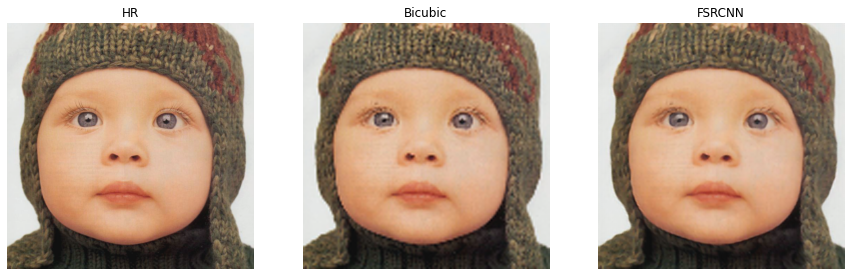

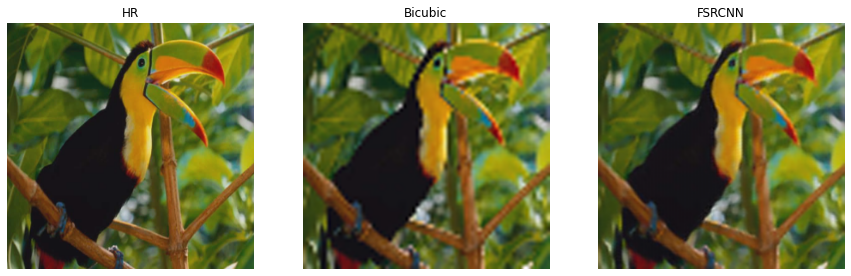

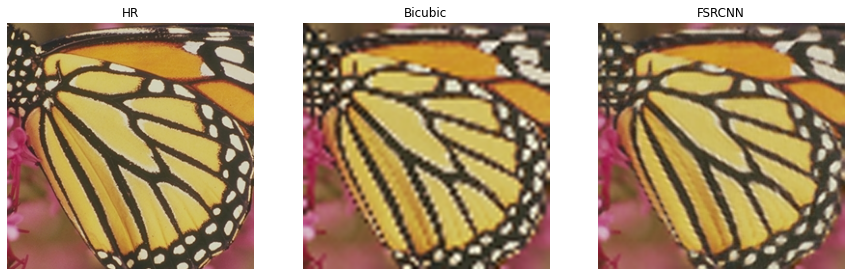

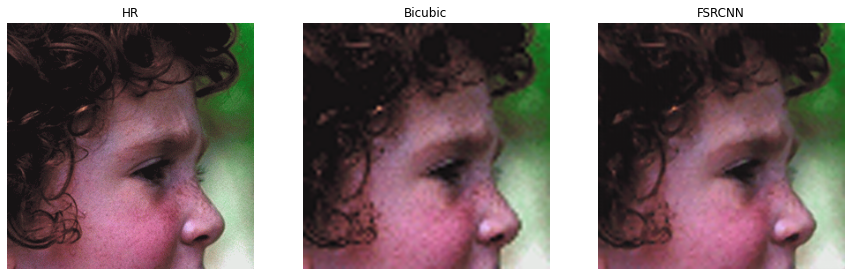

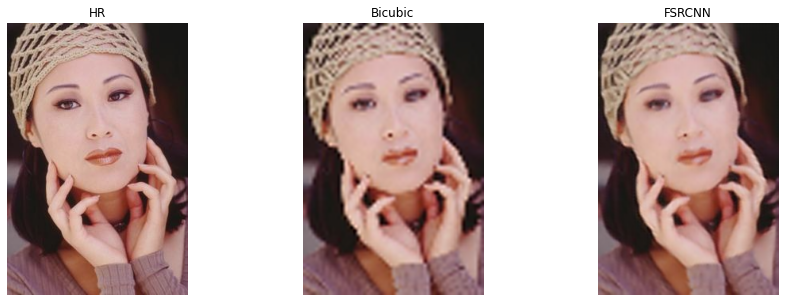

In [22]:
def ycbcr2rgb(im): # input image : ranges from 0 to 255
    xform = np.array([[1, 0, 1.402], [1, -0.34414, -.71414], [1, 1.772, 0]])
    rgb = im.astype(np.float64)#converts to float for calculation
    rgb[:,:,[1,2]] -= 128#shifts channels by 128
    rgb = rgb.dot(xform.T)#linear color transformation
    np.putmask(rgb, rgb > 255, 255)#clips value between 0 and 255.
    np.putmask(rgb, rgb < 0, 0)
    return np.uint8(rgb)

## Load best model
model.load_state_dict(torch.load("./weights/lab05/best_fsrcnn.pth", map_location=device))
model.eval()

with torch.no_grad():
    for (HR_img, LR_img, BC_img) in test_loader:
        HR_img, LR_img, BC_img = HR_img.to(device), LR_img.to(device), BC_img.to(device)

        # Feed only Y channel to the model
        SR_img = model(LR_img[:, 0:1, :, :])

        # Convert tensors to HWC numpy arrays
        hr_ycbcr = HR_img.squeeze(0).permute(1, 2, 0).cpu().numpy()
        bc_ycbcr = BC_img.squeeze(0).permute(1, 2, 0).cpu().numpy()
        sr_y = SR_img.squeeze().cpu().numpy()

        # Use predicted Y with bicubic Cb/Cr for RGB visualization
        sr_ycbcr = bc_ycbcr.copy()
        sr_ycbcr[:, :, 0] = sr_y

        hr_rgb = ycbcr2rgb((hr_ycbcr * 255.0).clip(0, 255))
        bc_rgb = ycbcr2rgb((bc_ycbcr * 255.0).clip(0, 255))
        sr_rgb = ycbcr2rgb((sr_ycbcr * 255.0).clip(0, 255))

        fig = plt.figure(figsize=(15, 5))
        ax1 = fig.add_subplot(1, 3, 1)
        ax2 = fig.add_subplot(1, 3, 2)
        ax3 = fig.add_subplot(1, 3, 3)

        ax1.imshow(hr_rgb)
        ax1.set_title("HR")
        ax1.axis("off")

        ax2.imshow(bc_rgb)
        ax2.set_title("Bicubic")
        ax2.axis("off")

        ax3.imshow(sr_rgb)
        ax3.set_title("FSRCNN")
        ax3.axis("off")

        plt.show()


## Results To Review

See the preserved output cells for training curves, metrics, predictions, visualizations, or heatmaps depending on the project. The repository README summarizes the main implementation choices and paper references.
